# EZIE Mag - Daily Data Notebook

**Project:** EZIE Mag Summer Research Project

This notebook loads one day's worth of EZIE-Mag summary data
(`.smr.60s.txt`, delivered as a daily `.zip` archive), and produces
labeled time-series plots of the magnetic field components:

- **Bx** <- North component (nT)
- **By** <- East component (nT)
- **Bz** <- Down component (nT)

**To use for a new day:** update `ZIP_PATH` in the Settings section
below, then run all cells.

## Data Format Reference

Each row of `.smr.60s.txt` is one 1-minute averaged record with the
following 24 fields (per `EZIE_Mag_Data_Format.docx`):

| Column | Type | Unit | Description |
|---|---|---|---|
| `timeString` | string | - | UTC time, ISO8601 format |
| `tval` | double | seconds | UTC time, UNIX epoch |
| `intt` | double | seconds | Integration time (60) |
| `nsamp` | integer | - | Number of raw mag samples averaged |
| `stid` | string | - | Station identifier |
| `fingerprint` | string | - | 12-character station fingerprint |
| `lat` | float | degrees | GPS latitude |
| `lon` | float | degrees | GPS longitude |
| `alt` | float | meters | GPS altitude |
| `tres` | integer | - | Temp sensor resolution (0=0.5°C ... 3=0.0625°C, most accurate) |
| `ctemp` | float | °C | Internal box temperature (MCP9808) |
| `ccr` | integer | - | RM3100 cycle count register |
| `Bx` | float | nT | Magnetic field X (**North**) |
| `By` | float | nT | Magnetic field Y (**East**) |
| `Bz` | float | nT | Magnetic field Z (**Down**) |
| `afs_sel` | integer | - | Accelerometer full-scale select (00=2g, 01=16g, 02=4g, 03=8g) |
| `fs_sel` | integer | - | Gyroscope full-scale select (00=250°/s, 01=500°/s, 02=1000°/s, 03=2000°/s) |
| `Ax`, `Ay`, `Az` | float | m/s² | Accelerometer X/Y/Z |
| `Gx`, `Gy`, `Gz` | float | °/s | Gyroscope X/Y/Z |
| `imu_ctemp` | float | °C | IMU temperature |

### Coordinate Frame
- **Bx = North**, **By = East**, **Bz = Down** (FRD convention)

### Affine Calibration (FRD alignment, for later work)
EZIE sensor axes may not align with true North/East/Down due to
mounting orientation, plus a small constant magnetic offset from the
electronics. Calibration uses:

$$[X, Y, Z]^T = A \cdot [B_x, B_y, B_z]^T + b$$

- **A** (3×3 matrix) - rotation/scale correction for sensor mounting
- **b** (3×1 vector) - hard-iron bias offset correction

Both are assumed constant over a measurement period (verified via
`checkStaticRotation.py`), so one `A, b` pair aligns all readings to
the FRD reference frame. Not yet implemented in this notebook.

## 1. Setup

Import required libraries and the project's helper module
(`ezie_utils.py`), which handles unzipping and loading the
`.smr.60s.txt` files.

In [15]:
# --- Standard library imports ---
import os            # for building file paths
import glob          # for finding files matching a pattern (e.g. *20260609*.zip)
import datetime      # for validating the user-entered date

# --- Third-party imports ---
import pandas as pd            # for DataFrames and time-based reindexing
import matplotlib.pyplot as plt  # for plotting Bx/By/Bz

# --- Project-specific module ---
# ezie_utils.py contains the unzip_day() and load_smr_files() functions
# that handle reading the raw .smr.60s.txt files into a DataFrame.
import ezie_utils

## 2. Settings

Enter the date (YYYYMMDD) for the day you want to process. The
notebook will automatically find the matching zip file in `rawdata/`.

In [16]:
# Folder where the zipped daily archives live (should never be modified)
RAWDATA_DIR = "rawdata"

# Folder where zip contents get extracted to (intermediate/displosable)
EXTRACT_TO = "extracted"

# Ask the user for a date, this is done instead of manually editing code to choose a specific day
date_str = input("Enter date (YYYYMMDD): ").strip()

# Validate the input
# Check that it's exactly 8 digits (YYYYMMDD format)
if not (date_str.isdigit() and len(date_str) == 8): # isdigit() checks every character is 0-9, len() checks its exactly 8 characters
    raise ValueError(
        f"Invalid date '{date_str}'. Please enter exactly 8 digits in YYYYMMDD format (e.g. 20260609)."
    )

# Check that it's actually a valid calendar date (catches things like month 13 or day 32)
try:
    datetime.datetime.strptime(date_str, "%Y%m%d") # strptime() will raise a ValueError on its own if given something
                                                   # like month=13 or day=32, so we catch that and give a clearer message
except ValueError:
    raise ValueError(
        f"'{date_str}' is not a valid date. Please enter a real date in YYYYMMDD format."
    )

# Find the matching zip file in rawdata/
# glob.glob() searches for files matching a wildcard pattern. "*20260609*.zip" matches any filename containing that date,
# regardless of whether dots, underscores, or other characters surround it (e.g. "eziemag.20260609.AAAAAIzs1uUA.zip")
matches = glob.glob(os.path.join(RAWDATA_DIR, f"*{date_str}*.zip"))

# Handles the possible outcomes of the search
if len(matches) == 0:
    # No file found - probably a typo, or that day's data hasn't been downloaded into rawdata/ yet
    raise FileNotFoundError(f"No zip file found for date {date_str} in {RAWDATA_DIR}/")
elif len(matches) > 1:
    # More than one file matched - naming collision, shouldn't normally happen but better to stop and flag it than guess
    raise ValueError(f"Multiple zip files match date {date_str}: {matches}")

# Exactly one match - this is the zip we'll process
ZIP_PATH = matches[0]
print("Using zip file:", ZIP_PATH)

Enter date (YYYYMMDD):  20260609


Using zip file: rawdata/eziemag.20260609.AAAAAIzs1uUA.zip


## 3. Load Data

Unzip the day's archive, locate the `.smr.60s.txt` file(s), and load
them into a single time-indexed DataFrame.

In [17]:
# Step 1: unzip and find the .smr.60s.txt file(s) for this day 
# unzip_day() extracts ZIP_PATH into EXTRACT_TO, then returns the list of .smr.60s.txt files found in that day's folder
# (extracted/home/ezie/smr.60s/<date>/)
smr_files = ezie_utils.unzip_day(ZIP_PATH, EXTRACT_TO)

print("Files found:")
for f in smr_files:
    print(" ", f)

# Step 2: load and combine those files into one DataFrame
# load_smr_files() reads each file, assigns the 24 column names, stacks them together, and sets a sorted datetime index
df = ezie_utils.load_smr_files(smr_files)

print("\nShape before gap-filling:", df.shape)
print("Time range:", df.index.min(), "to", df.index.max())
print()

# ---------------------------------------------------------------------
# Gap handling: fill in missing minutes so plots show real gaps
#
# Background: if data collection stops partway through the day (e.g. a power outage), the file simply has fewer rows - there's no
# placeholder for the missing minutes. If we plot this as-is, matplotlib draws a straight line connecting the last reading before
# the outage to the first reading after it, which is misleading (per the PPP "Power Outage - Data Gap" note).
#
# The fix: build a complete 1-minute-interval index covering the full day (00:00 to 23:59), and reindex our data onto that grid. Any
# minute we don't have real data for becomes a row of NaN. matplotlib automatically breaks line plots at NaN values, so the gap shows up
# as a visible break instead of a connecting line.
#
# TODO: move this gap-handling logic into ezie_utils.py as a reusable function (e.g. fill_day_gaps(df)) once the daily notebook is
# finalized. This will also be needed for the weekly notebook, so it shouldn't stay duplicated/inline like this long-term.
# ---------------------------------------------------------------------

# Step A: round each timestamp to the nearest minute.
# Raw timestamps have sub-second precision (e.g. ":22.020162600"), so they don't land exactly on clean minute boundaries. Rounding
# aligns them to :00 seconds so they'll match our 1-minute grid below.
df.index = df.index.round("1min")

# Step B: build a complete 1-minute grid for the whole day.
# - df.index.min().floor("D") rounds the first timestamp DOWN to midnight (00:00:00) of that day - this is our grid's start point
# - + 23 hours 59 minutes gives us the grid's end point (23:59)
# - freq="1min" means one timestamp per minute in between
# This produces exactly 1440 timestamps (24 hours x 60 minutes)
full_day_index = pd.date_range(
    start=df.index.min().floor("D"),
    end=df.index.min().floor("D") + pd.Timedelta(hours=23, minutes=59),
    freq="1min"
)

# Step C: reindex our data onto that grid.
# Rows that exist in df keep their values; minutes with no matching timestamp in df become new rows filled with NaN.
df = df.reindex(full_day_index)

print("Shape after gap-filling:", df.shape)
print("Missing rows (gap minutes):", df["Bx"].isna().sum())

df.head(10) # check

Files found:
  extracted/home/ezie/smr.60s/20260609/eziemag.2026060900.AAAAAIzs1uUA.smr.60s.txt
  extracted/home/ezie/smr.60s/20260609/eziemag.2026060901.AAAAAIzs1uUA.smr.60s.txt
  extracted/home/ezie/smr.60s/20260609/eziemag.2026060902.AAAAAIzs1uUA.smr.60s.txt
  extracted/home/ezie/smr.60s/20260609/eziemag.2026060903.AAAAAIzs1uUA.smr.60s.txt
  extracted/home/ezie/smr.60s/20260609/eziemag.2026060904.AAAAAIzs1uUA.smr.60s.txt
  extracted/home/ezie/smr.60s/20260609/eziemag.2026060905.AAAAAIzs1uUA.smr.60s.txt
  extracted/home/ezie/smr.60s/20260609/eziemag.2026060906.AAAAAIzs1uUA.smr.60s.txt
  extracted/home/ezie/smr.60s/20260609/eziemag.2026060907.AAAAAIzs1uUA.smr.60s.txt
  extracted/home/ezie/smr.60s/20260609/eziemag.2026060908.AAAAAIzs1uUA.smr.60s.txt
  extracted/home/ezie/smr.60s/20260609/eziemag.2026060909.AAAAAIzs1uUA.smr.60s.txt
  extracted/home/ezie/smr.60s/20260609/eziemag.2026060910.AAAAAIzs1uUA.smr.60s.txt
  extracted/home/ezie/smr.60s/20260609/eziemag.2026060911.AAAAAIzs1uUA.smr

,tval,intt,nsamp,stid,fingerprint,lat,lon,alt,tres,ctemp,...,Bz,afs_sel,fs_sel,Ax,Ay,Az,Gx,Gy,Gz,imu_ctemp
2026-06-09 00:00:00+00:00,1.780963e+09,60.0,1996.0,"""eziemag""",AAAAAIzs1uUA,32.952115,-97.255678,217.7,3.0,24.8125,...,-35567.546352,0.0,0.0,0.175274,-0.074776,9.806385,-0.002138,-0.004123,-0.005956,24.667969
2026-06-09 00:01:00+00:00,1.780963e+09,60.0,2025.0,"""eziemag""",AAAAAIzs1uUA,32.952115,-97.255678,217.7,3.0,24.8750,...,-35566.090853,0.0,0.0,0.164507,-0.087936,9.820742,-0.003665,-0.003360,-0.005803,24.656250
2026-06-09 00:02:00+00:00,1.780963e+09,60.0,2030.0,"""eziemag""",AAAAAIzs1uUA,32.952100,-97.255707,218.3,3.0,24.8750,...,-35567.062276,0.0,0.0,0.166301,-0.087338,9.817153,-0.003054,-0.004276,-0.005345,24.687500
2026-06-09 00:03:00+00:00,1.780963e+09,60.0,2033.0,"""eziemag""",AAAAAIzs1uUA,32.952100,-97.255707,218.3,3.0,24.8750,...,-35567.808014,0.0,0.0,0.162712,-0.077169,9.811769,-0.003360,-0.004429,-0.005651,24.679688
2026-06-09 00:04:00+00:00,1.780963e+09,60.0,2027.0,"""eziemag""",AAAAAIzs1uUA,32.952038,-97.255765,218.8,3.0,24.8125,...,-35567.978095,0.0,0.0,0.163310,-0.083151,9.808778,-0.003971,-0.003512,-0.005956,24.644531
2026-06-09 00:05:00+00:00,1.780964e+09,60.0,2029.0,"""eziemag""",AAAAAIzs1uUA,32.952038,-97.255765,218.8,3.0,24.8125,...,-35568.942976,0.0,0.0,0.166301,-0.089133,9.815358,-0.002596,-0.003971,-0.005345,24.664062
2026-06-09 00:06:00+00:00,1.780964e+09,60.0,2024.0,"""eziemag""",AAAAAIzs1uUA,32.952038,-97.255765,218.8,3.0,24.8125,...,-35567.755682,0.0,0.0,0.172881,-0.082552,9.814760,-0.003207,-0.003971,-0.005498,24.683594
2026-06-09 00:07:00+00:00,1.780964e+09,60.0,2026.0,"""eziemag""",AAAAAIzs1uUA,32.952103,-97.255730,220.4,3.0,24.8125,...,-35566.555304,0.0,0.0,0.156730,-0.086740,9.809974,-0.003054,-0.004429,-0.005803,24.644531
2026-06-09 00:08:00+00:00,1.780964e+09,60.0,2022.0,"""eziemag""",AAAAAIzs1uUA,32.952120,-97.255710,221.0,3.0,24.8125,...,-35566.234767,0.0,0.0,0.161516,-0.089133,9.805189,-0.003054,-0.004123,-0.005498,24.632812
2026-06-09 00:09:00+00:00,1.780964e+09,60.0,2029.0,"""eziemag""",AAAAAIzs1uUA,32.952090,-97.255708,221.0,3.0,24.8125,...,-35565.243720,0.0,0.0,0.162114,-0.080160,9.811171,-0.003360,-0.004276,-0.005651,24.613281


## 4. Daily Plots: Bx, By, Bz

Time-series plots of the three magnetic field components, in nT.
The x-axis uses real UTC timestamps, so any data gaps (e.g. from
power outages) appear naturally as breaks in the line.

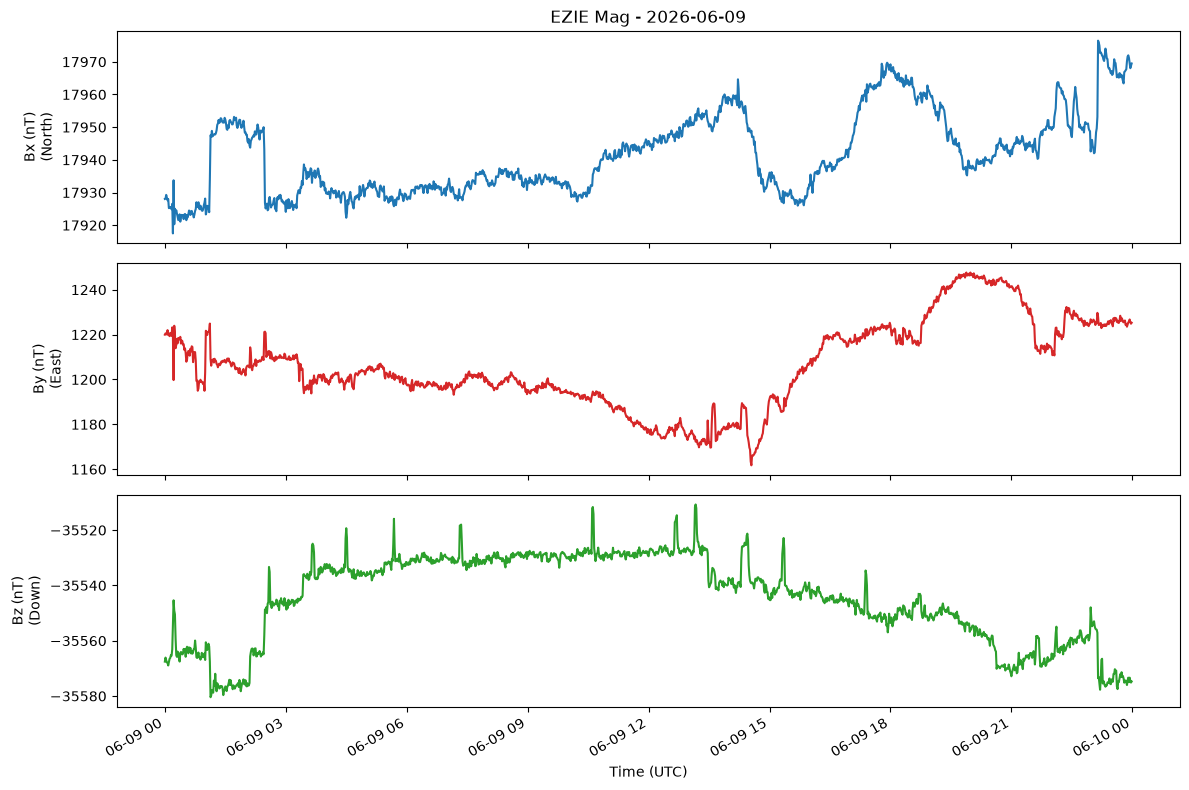

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df.index, df["Bx"], color="tab:blue")
axes[0].set_ylabel("Bx (nT)\n(North)")
axes[0].set_title(f"EZIE Mag - {df.index[0].date()}")

axes[1].plot(df.index, df["By"], color="tab:red")
axes[1].set_ylabel("By (nT)\n(East)")

axes[2].plot(df.index, df["Bz"], color="tab:green")
axes[2].set_ylabel("Bz (nT)\n(Down)")
axes[2].set_xlabel("Time (UTC)")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 5. Total Field Magnitude (|B|)

The total magnetic field magnitude combines all three components into
a single value:

$$|B| = \sqrt{B_x^2 + B_y^2 + B_z^2}$$

Unlike the individual X/Y/Z components, |B| doesn't depend on sensor
orientation - it represents the overall strength of the magnetic
field at the sensor's location, and is the quantity most often used
for comparison against reference

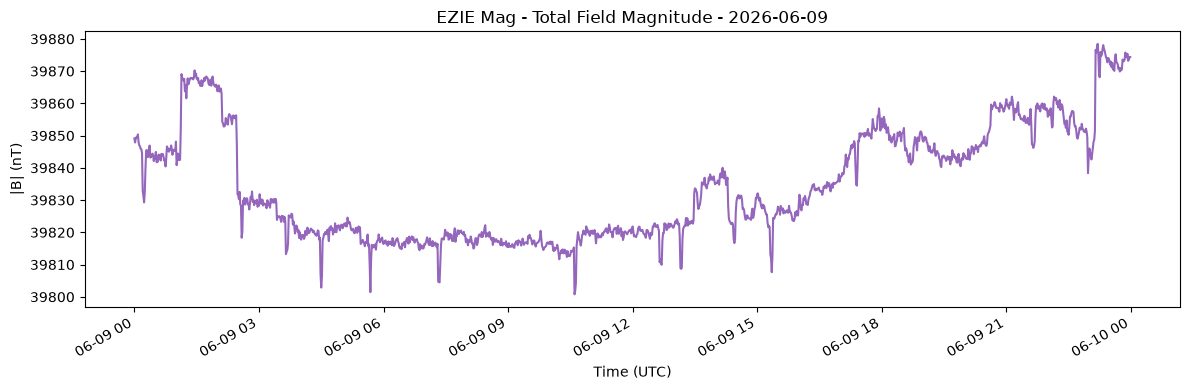

count     1439.000000
mean     39834.373171
std         17.454293
min      39800.776195
25%      39819.331881
50%      39828.875195
75%      39848.153438
max      39878.455940
Name: B_total, dtype: float64


In [19]:
# Calculate total field magnitude
# np.sqrt() and the ** operator work element-wise on pandas columns, so this computes |B| for every row (every minute) at once.
#
# NaN handling: if Bx, By, or Bz is NaN for a given minute (i.e. a gap-filled row from the missing-data handling above), the result
# of any arithmetic involving NaN is also NaN. So |B| will correctly be NaN during the outage gap, and matplotlib will break the line
# there too - consistent with the Bx/By/Bz plots.
df["B_total"] = (df["Bx"]**2 + df["By"]**2 + df["Bz"]**2) ** 0.5

# Plot it
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["B_total"], color="tab:purple")
ax.set_ylabel("|B| (nT)")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"EZIE Mag - Total Field Magnitude - {df.index[0].date()}")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# --- Quick summary stats ---
print(df["B_total"].describe())

## 6. Daily Plots (Central Time)

Same data as Section 4, but with the time axis converted to US
Central time for reference. The underlying data and gap-filling are
unchanged - only the displayed timestamps differ.

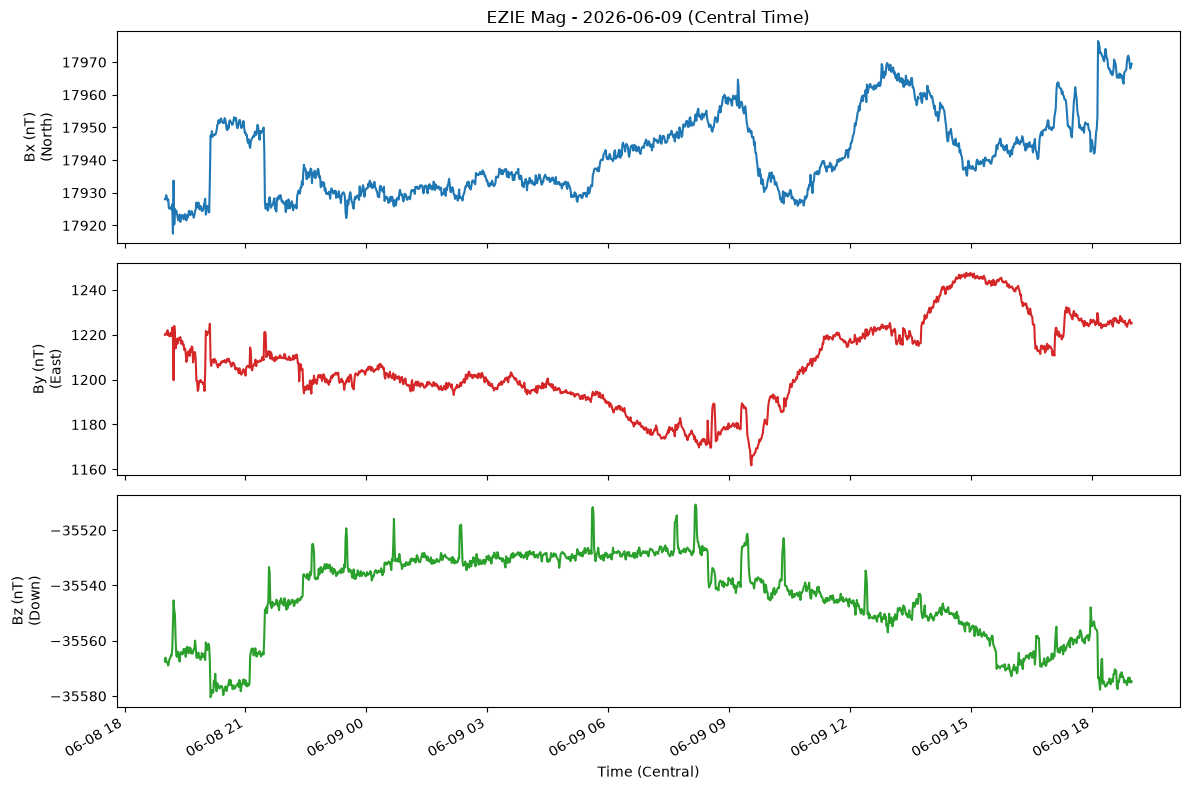

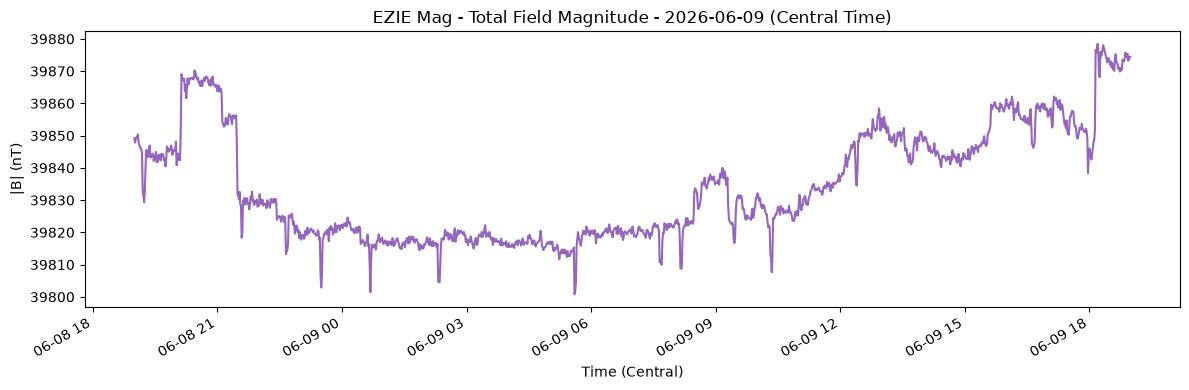

In [20]:
# Create a Central-time copy of the index for plotting
# tz_convert() shifts UTC timestamps to Central time, automatically handling CST (UTC-6) vs CDT (UTC-5) daylight saving.
#
# We use df.index.tz_convert(...) directly (not modifying df itself) so the original UTC-indexed df stays unchanged for any further
# analysis - this is purely for this plot's x-axis labels.
central_index = df.index.tz_convert("America/Chicago")

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(central_index, df["Bx"], color="tab:blue")
axes[0].set_ylabel("Bx (nT)\n(North)")
axes[0].set_title(f"EZIE Mag - {df.index[0].date()} (Central Time)")

axes[1].plot(central_index, df["By"], color="tab:red")
axes[1].set_ylabel("By (nT)\n(East)")

axes[2].plot(central_index, df["Bz"], color="tab:green")
axes[2].set_ylabel("Bz (nT)\n(Down)")
axes[2].set_xlabel("Time (Central)")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# |B| in Central time
# Same B_total values calculated in Section 5, just plotted against the Central-time index instead of UTC.
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(central_index, df["B_total"], color="tab:purple")
ax.set_ylabel("|B| (nT)")
ax.set_xlabel("Time (Central)")
ax.set_title(f"EZIE Mag - Total Field Magnitude - {df.index[0].date()} (Central Time)")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 7. Comparison with USGS FRD Observatory

This section pulls public reference data from the USGS Fredericksburg
(FRD) magnetic observatory - the same station referenced in
`EZIE_Mag_Data_Format.docx` for FRD-frame calibration - and overlays
it with the EZIE data for the same day.

**Important:** the EZIE sensor's Bx/By/Bz axes are NOT yet calibrated
to the FRD (North/East/Down) reference frame - per the data format
doc, this requires the affine transform `[X,Y,Z]^T = A[Bx,By,Bz]^T + b`
which has not been implemented yet. So this overlay is a rough visual
comparison only; absolute values and offsets will not match until
calibration is applied. Trends/shape similarity is the useful signal
here for now.

Requires the `requests` library (`pip install requests` if not
already installed).

In [21]:
import requests

# --- Build the request to USGS's GeoMag web service ---
# id=FRD          -> Fredericksburg observatory (the reference station
#                    named in EZIE_Mag_Data_Format.docx)
# elements=X,Y,Z,F -> request North, East, Down, and total field
# sampling_period=60 -> 1-minute data, matching our EZIE cadence
# format=json     -> easiest to parse into a DataFrame

# Build start/end times to match the same UTC day as our EZIE data.
# df.index is currently in UTC (before any timezone conversion),
# so we can use its date directly.
day_start = df.index.min().floor("D")
day_end = day_start + pd.Timedelta(days=1)

frd_url = (
    "https://geomag.usgs.gov/ws/data/"
    f"?id=FRD"
    f"&starttime={day_start.strftime('%Y-%m-%dT%H:%M:%SZ')}"
    f"&endtime={day_end.strftime('%Y-%m-%dT%H:%M:%SZ')}"
    f"&elements=X,Y,Z,F"
    f"&sampling_period=60"
    f"&format=json"
)

print("Requesting:", frd_url)

response = requests.get(frd_url)
response.raise_for_status()  # raises an error if the request failed
frd_json = response.json()

# --- Parse the JSON into a DataFrame ---
# "times" is a list of ISO8601 timestamp strings, shared across all
# elements. "values" is a list of {metadata, values} dicts, one per
# requested element (X, Y, Z, F).
frd_times = pd.to_datetime(frd_json["times"])

frd_df = pd.DataFrame(index=frd_times)
for element in frd_json["values"]:
    name = element["metadata"]["element"]  # e.g. "X", "Y", "Z", "F"
    frd_df[name] = element["values"]

print("FRD data shape:", frd_df.shape)
frd_df.head()

Requesting: https://geomag.usgs.gov/ws/data/?id=FRD&starttime=2026-06-09T00:00:00Z&endtime=2026-06-10T00:00:00Z&elements=X,Y,Z,F&sampling_period=60&format=json
FRD data shape: (1441, 4)


,X,Y,Z,F
2026-06-09 00:00:00+00:00,21392.010,-3976.132,45113.885,50088.289
2026-06-09 00:01:00+00:00,21391.866,-3975.875,45113.814,50088.138
2026-06-09 00:02:00+00:00,21391.491,-3975.846,45113.783,50087.972
2026-06-09 00:03:00+00:00,21391.193,-3975.869,45113.703,50087.781
2026-06-09 00:04:00+00:00,21391.141,-3975.615,45113.580,50087.597


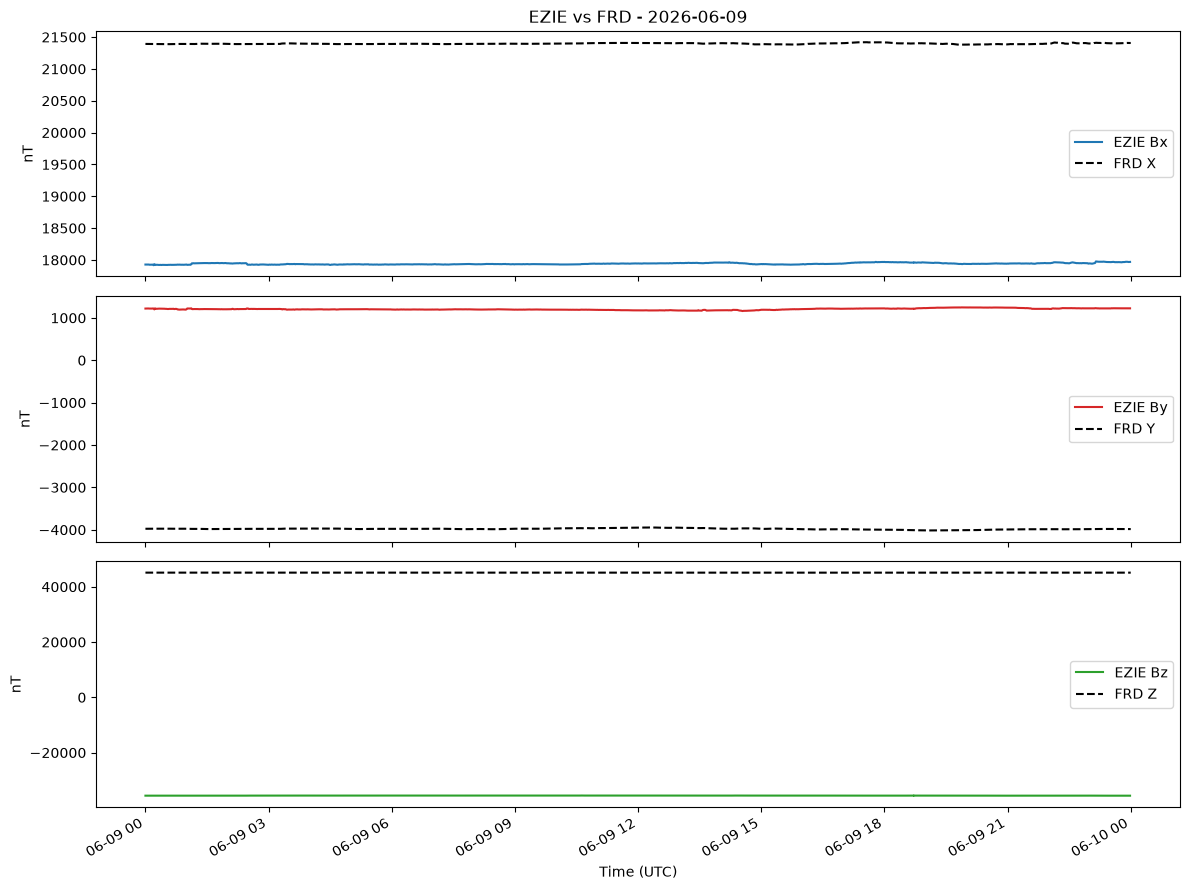

In [22]:
# --- Overlay EZIE (Bx/By/Bz) with FRD (X/Y/Z) on shared axes ---
# Note: EZIE axes are NOT yet calibrated to FRD's frame, so values
# won't align numerically - this is a shape/trend comparison only.
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# --- North component: EZIE Bx vs FRD X ---
axes[0].plot(df.index, df["Bx"], color="tab:blue", label="EZIE Bx")
axes[0].plot(frd_df.index, frd_df["X"], color="black", linestyle="--", label="FRD X")
axes[0].set_ylabel("nT")
axes[0].set_title(f"EZIE vs FRD - {df.index[0].date()}")
axes[0].legend()

# --- East component: EZIE By vs FRD Y ---
axes[1].plot(df.index, df["By"], color="tab:red", label="EZIE By")
axes[1].plot(frd_df.index, frd_df["Y"], color="black", linestyle="--", label="FRD Y")
axes[1].set_ylabel("nT")
axes[1].legend()

# --- Down component: EZIE Bz vs FRD Z ---
axes[2].plot(df.index, df["Bz"], color="tab:green", label="EZIE Bz")
axes[2].plot(frd_df.index, frd_df["Z"], color="black", linestyle="--", label="FRD Z")
axes[2].set_ylabel("nT")
axes[2].set_xlabel("Time (UTC)")
axes[2].legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()